In [56]:
# Bias Detection in Model
# Focus on 3 models
# 1. Logistic Regression
# 2. Random Forest
# 3. Neural Network

In [57]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import(
    accuracy_score, 
    roc_auc_score, 
    ConfusionMatrixDisplay, 
    confusion_matrix, 
    classification_report, 
    precision_score, 
    recall_score,
    f1_score,
    brier_score_loss
)
import matplotlib.pyplot as plt
import seaborn as sns
import shap

In [66]:
# Shap explainability helper functions
def _safe_feature_names(X):
    def _safe_feature_names(X):
        if isinstance(X, pd.DataFrame):
            return X.columns.tolist()
        return [f"f{i}" for i in range(X.shape[1])]

def plot_and_save(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.close()

# Linear Regression explainability
def shap_logistic(
    lr_model,
    X_train,
    X_test,
    out_prefix="LR",
    explain_n=800,
    seed=42):
    X_train_df = X_train if isinstance(X_train, pd.DataFrame) else pd.DataFrame(
        X_train, columns=_safe_feature_names(X_train)
    )
    X_test_df = X_test if isinstance(X_test, pd.DataFrame) else pd.DataFrame(
        X_test, columns=_safe_feature_names(X_test)
    )

    # Sample rows to explain (Solution 1 approach)
    rng = np.random.default_rng(seed)
    n = min(explain_n, len(X_test_df))
    sample_idx = rng.choice(X_test_df.index, size=n, replace=False)
    X_explain_df = X_test_df.loc[sample_idx]

    # Build explainer (LinearExplainer is fast for LR)
    explainer = shap.LinearExplainer(
        lr_model,
        X_train_df,
        feature_perturbation="interventional"
    )

    shap_values = explainer(X_explain_df)  # shap.Explanation

    # Global summary (beeswarm)
    shap.plots.beeswarm(shap_values, max_display=20, show=False)
    plot_and_save(f"{out_prefix}_shap_beeswarm.png")

    # Global importance (bar)
    shap.plots.bar(shap_values, max_display=20, show=False)
    plot_and_save(f"{out_prefix}_shap_bar.png")

    return shap_values, X_explain_df


# Random forest explainability
def shap_random_forest(
    rf_model,
    X_test,
    out_prefix="RF",
    explain_n=150,
    seed=42,
    check_additivity=False
):
    # Ensure DataFrame (preserve exact training columns/order!)
    X_test_df = X_test if isinstance(X_test, pd.DataFrame) else pd.DataFrame(X_test)

    # Sample rows to explain
    rng = np.random.default_rng(seed)
    n = min(explain_n, len(X_test_df))
    idx = rng.choice(X_test_df.index, size=n, replace=False)
    X_explain = X_test_df.loc[idx]

    # TreeExplainer (fast for RF)
    explainer = shap.TreeExplainer(rf_model, feature_perturbation="tree_path_dependent")

    # Get SHAP values as Explanation object
    shap_values = explainer(X_explain)

    # For binary classification, select positive class if multi-dimensional
    if shap_values.values.ndim == 3:
        shap_values = shap.Explanation(
            values=shap_values.values[:, :, 1],
            base_values=shap_values.base_values[:, 1] if shap_values.base_values.ndim > 1 else shap_values.base_values,
            data=shap_values.data,
            feature_names=shap_values.feature_names
        )

    # For binary classification, shap_values is already for the positive class
    sv = shap_values.values

    # Beeswarm
    shap.plots.beeswarm(shap_values, max_display=20, show=False)
    plot_and_save(f"{out_prefix}_shap_beeswarm.png")

    # Bar
    shap.plots.bar(shap_values, max_display=20, show=False)
    plot_and_save(f"{out_prefix}_shap_bar.png")

    return sv, X_explain


# Neural networks Explainability
def shap_neural_net(nn_model, X_train, X_test, out_prefix="NN", background_n=200, explain_n=400, seed=42):
    rng = np.random.default_rng(seed)

    X_train_df = X_train if isinstance(X_train, pd.DataFrame) else pd.DataFrame(X_train, columns=_safe_feature_names(X_train))
    X_test_df  = X_test  if isinstance(X_test, pd.DataFrame)  else pd.DataFrame(X_test,  columns=_safe_feature_names(X_test))

    # sample background + explained rows
    bg_idx = rng.choice(len(X_train_df), size=min(background_n, len(X_train_df)), replace=False)
    ex_idx = rng.choice(len(X_test_df),  size=min(explain_n, len(X_test_df)),  replace=False)

    background = X_train_df.iloc[bg_idx]
    explain_X  = X_test_df.iloc[ex_idx]

    def f(X):
        X = pd.DataFrame(X, columns=X_test_df.columns)
        # if your model has predict_proba
        return nn_model.predict_proba(X)[:, 1]

    explainer = shap.KernelExplainer(f, background)
    shap_vals = explainer.shap_values(explain_X, nsamples=200)  # increase if needed
    shap_values = shap.Explanation(values=shap_vals, data=explain_X.values, feature_names=explain_X.columns)

    shap.plots.beeswarm(shap_values, max_display=20, show=False)
    plot_and_save(f"{out_prefix}_shap_beeswarm.png")

    shap.plots.bar(shap_values, max_display=20, show=False)
    plot_and_save(f"{out_prefix}_shap_bar.png")

    return shap_values, explain_X


# Comparison
def group_shap_comparison(shap_values, X_df, groups_series, top_k=12, out_prefix="GROUP"):
    # shap_values.values shape: (n, d)
    S = np.abs(shap_values.values)
    feature_names = list(X_df.columns)

    df_shap = pd.DataFrame(S, columns=feature_names)
    df_shap["group"] = groups_series.values

    group_means = df_shap.groupby("group")[feature_names].mean()

    # pick top_k globally important features
    global_rank = df_shap[feature_names].mean().sort_values(ascending=False).head(top_k).index.tolist()
    group_top = group_means[global_rank].T  # features x groups

    # save table
    group_top.to_csv(f"{out_prefix}_mean_abs_shap_by_group.csv")

    # plot
    group_top.plot(kind="bar", figsize=(14,6))
    plt.title("Mean |SHAP| by Group (Top Features)")
    plt.ylabel("Mean |SHAP|")
    plt.xlabel("Feature")
    plt.legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left")
    plot_and_save(f"{out_prefix}_mean_abs_shap_by_group.png")

    return group_top



In [59]:
# Load and preprocess data
df = pd.read_csv('../../datasets/recruitment.csv')

# data information
print(df.head())
print(df.shape)

# Clean dataset


# Encoding categorical variables
df['Age_Group'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 65], labels=['18-25', '26-35', '36-45', '46-55', '56-65'])

df['Selected'] = df['Selected'].map({'Yes': 1, 'No': 0})

df.drop(columns=['Candidate_ID', 'Age'], inplace=True)

mlb = MultiLabelBinarizer()
skills_df = df.copy()

skills_df['Skills'] = skills_df['Skills'].fillna('').str.lower().str.split(',')

skills_encoded = pd.DataFrame(mlb.fit_transform(skills_df['Skills']),
                              columns=[f"skill_{s.replace(' ', '_')}" for s in mlb.classes_])

skills_df = pd.concat([df.drop(columns=['Skills']), skills_encoded], axis=1)

categorical_cols = ['Gender', 'Race', 'Education', 'Age_Group', "Certifications"]


df_encoded = skills_df.copy()

for col in categorical_cols:
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

skills_cols = [col for col in df_encoded.columns if col.startswith('skill_')]

skills_cols = [col for col in df_encoded.columns if col.startswith('skill_')]
numerical_cols = ["Experience_Years", "Screening_Score", "Selected"]

df_encoded = df_encoded[categorical_cols + numerical_cols + skills_cols]

                           Candidate_ID  Gender      Race  Age Education  \
0  mostlyfa-2bdb-493a-a0f3-ed9ab51f7aa9  Female     White   28  Bachelor   
1  mostly49-894b-433c-9d43-0030178044f6    Male  Hispanic   48    Master   
2  mostlye8-47a9-4acb-ac11-63f4219927cf  Female     White   31    Master   
3  mostlyed-12b8-4915-825e-951390b65f19    Male  Hispanic   36  Bachelor   
4  mostlye1-ac47-48d0-81ce-9ff776545637  Female  Hispanic   29       PhD   

   Experience_Years   Job_Role_Applied  \
0                20  Software Engineer   
1                 0     Data Scientist   
2                16  Software Engineer   
3                21  Software Engineer   
4                22    Project Manager   

                                           Skills Certifications  \
0                                          _RARE_            NaN   
1                                Python, Git, SQL            PMP   
2                                          _RARE_            PMP   
3                 

In [60]:
# Prepare features and target
X = df_encoded.drop(columns=['Selected'])  # drop non-feature columns
y = df_encoded['Selected']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Performance Metrics 
# accuracy, ROC-AUC, Recall, Precision, F1-Score
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()

    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None


    print(classification_report(y_test, y_pred, target_names = ["Yes", "No"]))

    return {
        'accuracy': accuracy,
        'roc_auc': roc_auc
    }

/opt/anaconda3/lib/python3.12/site-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


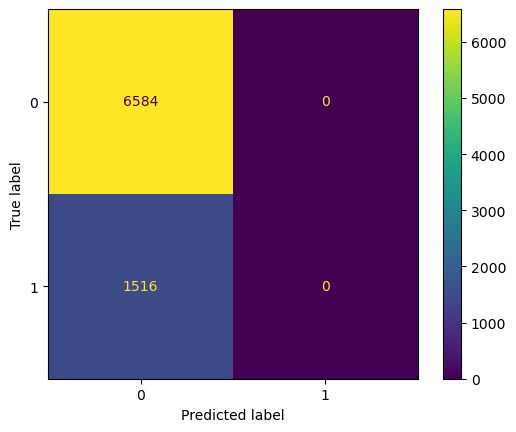

              precision    recall  f1-score   support

         Yes       0.81      1.00      0.90      6584
          No       0.00      0.00      0.00      1516

    accuracy                           0.81      8100
   macro avg       0.41      0.50      0.45      8100
weighted avg       0.66      0.81      0.73      8100

Logistic Regression Performance: {'accuracy': 0.8128395061728395, 'roc_auc': 0.5643498510821789}


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [61]:
# Logistic Regression
logistic_regression_model = LogisticRegression(max_iter=1000)
logistic_regression_model.fit(X_train, y_train)

shap_logistic(logistic_regression_model, X_train, X_test)

print("Logistic Regression Performance:", evaluate_model(logistic_regression_model, X_test, y_test))

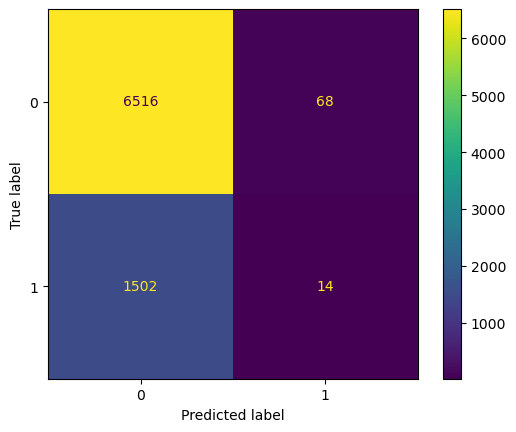

              precision    recall  f1-score   support

         Yes       0.81      0.99      0.89      6584
          No       0.17      0.01      0.02      1516

    accuracy                           0.81      8100
   macro avg       0.49      0.50      0.46      8100
weighted avg       0.69      0.81      0.73      8100

Random Forest Performance: {'accuracy': 0.8061728395061728, 'roc_auc': 0.5293995978898233}


In [67]:
# Random Forest
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

sv_rf, X_rf_explain = shap_random_forest(random_forest_model, X_test, explain_n=100)

print("Random Forest Performance:", evaluate_model(random_forest_model, X_test, y_test))

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/400 [00:00<?, ?it/s]

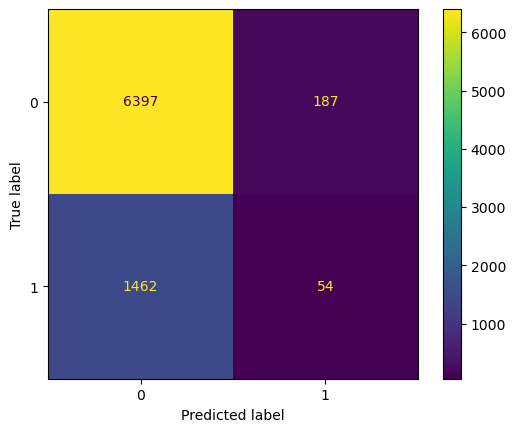

              precision    recall  f1-score   support

         Yes       0.81      0.97      0.89      6584
          No       0.22      0.04      0.06      1516

    accuracy                           0.80      8100
   macro avg       0.52      0.50      0.47      8100
weighted avg       0.70      0.80      0.73      8100

Neural Network Performance: {'accuracy': 0.7964197530864198, 'roc_auc': 0.5226412394964044}


In [ ]:
# Neural Network
neural_network_model = MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42)
neural_network_model.fit(X_train, y_train)

shap_neural_net(neural_network_model, X_train, X_test)

print("Neural Network Performance:", evaluate_model(neural_network_model, X_test, y_test))

In [ ]:
# Quantify and compare how each model’s predictions differ across demographic groups (Gender, Race, Age) to:

# Identify which model is most fair,

# Understand where unfair influence comes from,

# And evaluate the fairness–accuracy trade-off.

In [ ]:
def group_binary_metrics(y_true, y_pred, y_prob, group):
    """
    Computes key binary classification metrics for each demographic group.

    Parameters:
    -----------
    y_true : array-like
        Ground truth labels (0/1)
    y_pred : array-like
        Model's binary predictions
    y_prob : array-like
        Model's predicted probabilities
    group : array-like
        Sensitive attribute values (e.g., Gender, Race, Age)

    Returns:
    --------
    DataFrame summarizing metrics per group and overall
    """
    data = pd.DataFrame({
        'y_true': y_true.astype(int),
        'y_pred': y_pred.astype(int),
        'y_prob': y_prob.astype(float),
        'group': group.astype(str)
    })

    rows = []
    for g, df_g in data.groupby('group'):
        n = len(df_g)
        pos = df_g['y_true'].sum()
        neg = n - pos

        # confusion matrix
        tn, fp, fn, tp = confusion_matrix(df_g['y_true'], df_g['y_pred'], labels=[0, 1]).ravel()

        # compute rates
        sr = df_g['y_pred'].mean()  # selection rate
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        ppv = precision_score(df_g['y_true'], df_g['y_pred'], zero_division=0)
        rec = recall_score(df_g['y_true'], df_g['y_pred'], zero_division=0)
        f1 = f1_score(df_g['y_true'], df_g['y_pred'], zero_division=0)

        auc = roc_auc_score(df_g['y_true'], df_g['y_prob']) if df_g['y_true'].nunique() == 2 else np.nan
        brier = brier_score_loss(df_g['y_true'], df_g['y_prob'])

        rows.append({
            'group': g, 'n': n, 'pos': int(pos), 'neg': int(neg),
            'SR': sr, 'TPR': tpr, 'FPR': fpr, 'PPV': ppv, 'Recall': rec, 'F1': f1,
            'ROC_AUC': auc, 'Brier': brier
        })

    dfm = pd.DataFrame(rows).sort_values('group').reset_index(drop=True)
    return dfm

In [ ]:
def fairness_gaps(dfm, ref_group=None):
    """
    Computes fairness gaps vs. a reference group.

    Parameters:
    -----------
    dfm : DataFrame
        Output of group_binary_metrics()
    ref_group : str, optional
        The reference group to compare others against.
        If None, the group with highest Selection Rate (SR) is used.

    Returns:
    --------
    DataFrame with fairness metrics and flags.
    """
    base = dfm.copy()

    # Select reference (group with highest SR by default)
    if ref_group is None:
        ref_group = base.loc[base['SR'].idxmax(), 'group']

    ref = base[base['group'] == ref_group].iloc[0]

    # Compute fairness deltas and ratios
    base['SPD'] = base['SR'] - ref['SR']               # Statistical Parity Difference
    base['DI'] = base['SR'] / ref['SR'] if ref['SR'] > 0 else np.nan  # Disparate Impact
    base['EOD'] = base['TPR'] - ref['TPR']             # Equal Opportunity Difference
    base['EO_FPR'] = base['FPR'] - ref['FPR']          # Equalized Odds (FPR)
    base['ΔPPV'] = base['PPV'] - ref['PPV']            # Predictive Parity Difference
    base['Ref_Group'] = ref_group

    # Flag fairness violations
    def flag(row):
        issues = []
        if row['DI'] < 0.8: issues.append('Adverse Impact (DI<0.8)')
        if abs(row['EOD']) > 0.10: issues.append('TPR gap > 0.10')
        if abs(row['EO_FPR']) > 0.10: issues.append('FPR gap > 0.10')
        if abs(row['ΔPPV']) > 0.10: issues.append('PPV gap > 0.10')
        return ', '.join(issues) if issues else 'OK'

    base['Fairness_Flag'] = base.apply(flag, axis=1)
    return base


In [ ]:
def flip_binary_column(X, col):
    # Assumes a one-hot or binary col; for one-hot, swap *_Male and *_Female, etc.
    x = X.copy()
    if col in x.columns and set(x[col].unique())<=set([0,1]):
        x[col] = 1 - x[col]
    return x

def counterfactual_audit(model, X, feature_to_flip):
    Xf = flip_binary_column(X, feature_to_flip)
    p0 = model.predict_proba(X)[:,1]
    p1 = model.predict_proba(Xf)[:,1]
    diffs = np.abs(p0 - p1)
    return {
        'feature': feature_to_flip,
        'avg_change': float(np.mean(diffs)),
        'max_change': float(np.max(diffs)),
        'pct_changed_ge_0_05': float((diffs>=0.05).mean()*100)
    }

In [ ]:
# Ground truth
df_test = df_encoded.copy()
# align ground truth & group columns to the test split
df_test = df_encoded.loc[X_test.index].copy()   # rows corresponding to X_test
y_true = y_test.astype(int)

# Model predictions
y_prob_lr  = logistic_regression_model.predict_proba(X_test)[:,1]
y_prob_rf  = random_forest_model.predict_proba(X_test)[:,1]

# For the neural network, prefer predict_proba; handle shapes safely
if hasattr(neural_network_model, "predict_proba"):
    probs_nn = neural_network_model.predict_proba(X_test)
    if probs_nn.ndim == 1:
        y_prob_nn = probs_nn
    else:
        # binary case: take probability of class 1
        y_prob_nn = probs_nn[:, 1] if probs_nn.shape[1] > 1 else probs_nn[:, 0]
else:
    # fallback: use predict (labels) as 0/1 probabilities
    y_prob_nn = neural_network_model.predict(X_test).astype(float)


# Threshold at 0.5 (can tune later)
y_pred_lr = (y_prob_lr >= 0.5).astype(int)
y_pred_rf = (y_prob_rf >= 0.5).astype(int)
y_pred_nn = (y_prob_nn >= 0.5).astype(int)


In [ ]:
sensitive_attributes = ['Gender', 'Race', 'Age_Group']

def model_bias_report(name, y_true, y_pred, y_prob, group_col):
    m = group_binary_metrics(y_true, y_pred, y_prob, group_col)
    print(f"Bias Report for {name} by {group_col.name}")
    g = fairness_gaps(m)
    g['Model'] = name
    return g

In [ ]:
all_reports = []

for attr in sensitive_attributes:
    all_reports.append(model_bias_report('LogisticRegression', y_true, y_pred_lr, y_prob_lr, df_test[attr]))
    all_reports.append(model_bias_report('RandomForest', y_true, y_pred_rf, y_prob_rf, df_test[attr]))
    all_reports.append(model_bias_report('NeuralNetwork', y_true, y_pred_nn, y_prob_nn, df_test[attr]))

df_fairness = pd.concat(all_reports, ignore_index=True)


summary = df_fairness.groupby(['Model', 'group']).agg({
    'SR': 'mean', 'DI': 'mean', 'EOD': 'mean', 'EO_FPR': 'mean', 'ROC_AUC': 'mean'
}).reset_index()

summary.sort_values(['Model','group'], inplace=True)
summary



Bias Report for LogisticRegression by Gender
Bias Report for RandomForest by Gender
Bias Report for NeuralNetwork by Gender
Bias Report for LogisticRegression by Race
Bias Report for RandomForest by Race
Bias Report for NeuralNetwork by Race
Bias Report for LogisticRegression by Age_Group
Bias Report for RandomForest by Age_Group
Bias Report for NeuralNetwork by Age_Group


,Model,group,SR,DI,EOD,EO_FPR,ROC_AUC
0,LogisticRegression,0,0.000000,NaN,0.000000,0.000000,0.572661
1,LogisticRegression,1,0.000000,NaN,0.000000,0.000000,0.561517
2,LogisticRegression,2,0.000000,NaN,0.000000,0.000000,0.555535
3,LogisticRegression,3,0.000000,NaN,0.000000,0.000000,0.543176
4,LogisticRegression,4,0.000000,NaN,0.000000,0.000000,0.504232
5,NeuralNetwork,0,0.030050,0.677424,-0.021734,-0.015484,0.521883
6,NeuralNetwork,1,0.035493,0.787538,-0.013952,-0.010846,0.515561
7,NeuralNetwork,2,0.031926,0.714075,-0.016441,-0.014709,0.522540
8,NeuralNetwork,3,0.023715,0.447159,-0.039055,-0.026370,0.517719
9,NeuralNetwork,4,0.039762,0.700272,-0.013487,-0.012399,0.550382


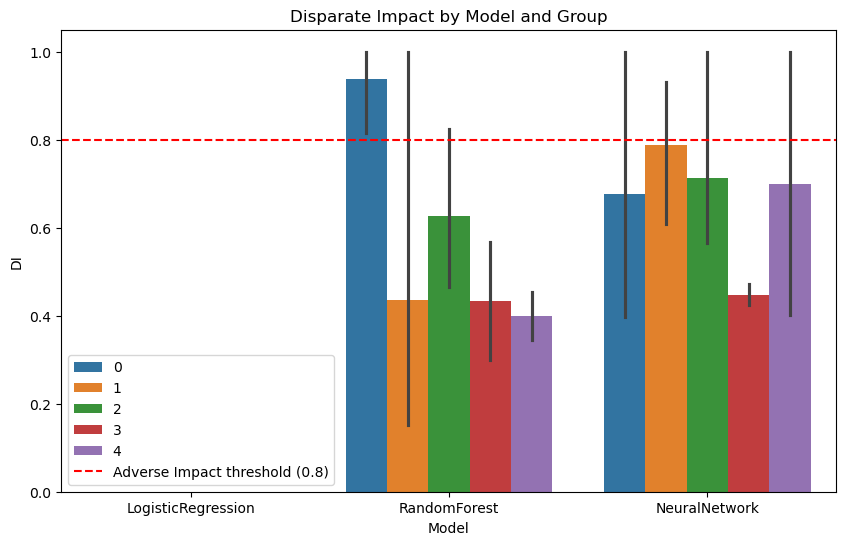

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_fairness, x='Model', y='DI', hue='group')
plt.axhline(0.8, color='red', linestyle='--', label='Adverse Impact threshold (0.8)')
plt.title('Disparate Impact by Model and Group')
plt.legend()
plt.show()


In [ ]:
cf_lr = counterfactual_audit(logistic_regression_model, X_test, 'Gender_Male')
cf_rf = counterfactual_audit(random_forest_model, X_test, 'Gender_Male')
cf_nn = counterfactual_audit(neural_network_model, X_test, 'Gender_Male')

cf_summary = pd.DataFrame([cf_lr, cf_rf, cf_nn])
cf_summary


,feature,avg_change,max_change,pct_changed_ge_0_05
0,Gender_Male,0.0,0.0,0.0
1,Gender_Male,0.0,0.0,0.0
2,Gender_Male,0.0,0.0,0.0
